In [1]:
import numpy as np

# a. Store the input and filter using NumPy arrays
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

# Parameters
stride = 1
padding = 0

# Get dimensions
in_h, in_w = input_matrix.shape
k_h, k_w = kernel.shape

# Calculate output dimensions: Output = ((Input - Filter + 2*Padding) / Stride) + 1
out_h = int((in_h - k_h + 2 * padding) / stride) + 1
out_w = int((in_w - k_w + 2 * padding) / stride) + 1

# Initialize the output feature map with zeros
output_map = np.zeros((out_h, out_w))

# b. Slide the filter over the input matrix & c. Compute the dot product
for r in range(out_h):
    for c in range(out_w):
        # Define the current window on the input
        row_start = r * stride
        row_end = row_start + k_h
        col_start = c * stride
        col_end = col_start + k_w

        window = input_matrix[row_start:row_end, col_start:col_end]

        # Element-wise multiplication and summation (dot product)
        output_map[r, c] = np.sum(window * kernel)

# d. Print the complete output feature map
print("Output Feature Map:")
print(output_map)

# e. Print the output shape
print("\nOutput Shape:")
print(output_map.shape)

Output Feature Map:
[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]

Output Shape:
(3, 3)


### f. Explanation of changing Stride from 1 to 2

Changing the **stride from 1 to 2** would have the following effects:
1. **Reduction in Output Dimensions:** The filter would slide 2 pixels at a time instead of 1. According to the output size formula $O = \lfloor\frac{I - K}{S}\rfloor + 1$ (for padding = 0):
   - With $S = 1$: $O = \lfloor\frac{5 - 3}{1}\rfloor + 1 = 3 \times 3$.
   - With $S = 2$: $O = \lfloor\frac{5 - 3}{2}\rfloor + 1 = 2 \times 2$.
   Thus, the output feature map would shrink from a $3 \times 3$ matrix to a $2 \times 2$ matrix.
2. **Information Loss:** It downsamples the input more aggressively, leading to a loss of spatial resolution and potentially missing fine-grained local features.

Using device: cpu
Running Experiment A (Feature Extraction)... 
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 253MB/s]


Trainable Parameters (Experiment A): 1026
Accuracy: 52.00%, Training Time: 6.16 seconds

Running Experiment B (Fine-Tuning)... 
Trainable Parameters (Experiment B): 8394754
Accuracy: 42.00%, Training Time: 10.26 seconds



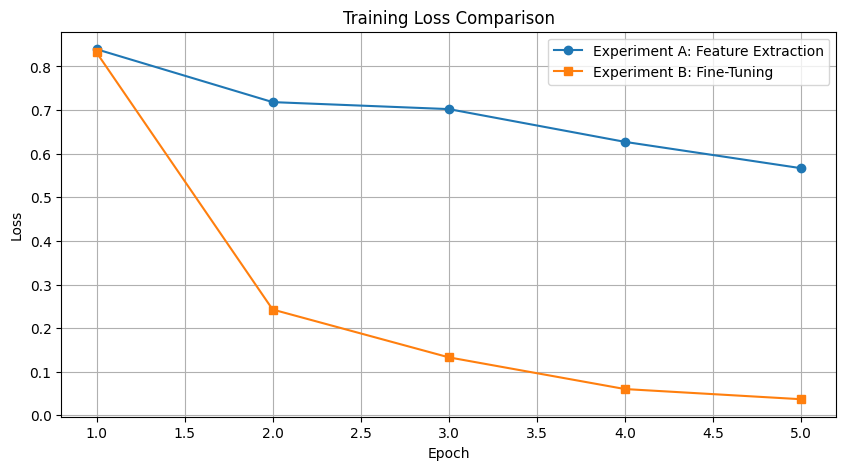

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Create a Synthetic Dataset (Binary Classification, 3-channel images)
# 200 samples of 3x64x64 images for training, 50 for validation
np.random.seed(42)
torch.manual_seed(42)

X_train = torch.randn(200, 3, 64, 64)
y_train = torch.randint(0, 2, (200,))
X_val = torch.randn(50, 3, 64, 64)
y_val = torch.randint(0, 2, (50,))

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, criterion, optimizer, num_epochs=5):
    start_time = time.time()
    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        loss_history.append(epoch_loss)

    total_time = time.time() - start_time

    # Validation Accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    return loss_history, total_time, val_acc

# --- EXPERIMENT A: Feature Extraction (Frozen Base) ---
print("Running Experiment A (Feature Extraction)... ")
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze convolutional base
for param in model_fe.parameters():
    param.requires_grad = False

# Replace final fully connected layer for binary classification
num_ftrs = model_fe.fc.in_features
model_fe.fc = nn.Linear(num_ftrs, 2)
model_fe = model_fe.to(device)

params_fe = count_trainable_params(model_fe)
print(f"Trainable Parameters (Experiment A): {params_fe}")

criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=0.001)

loss_fe, time_fe, acc_fe = train_model(model_fe, criterion, optimizer_fe, num_epochs=5)
print(f"Accuracy: {acc_fe * 100:.2f}%, Training Time: {time_fe:.2f} seconds\n")

# --- EXPERIMENT B: Fine-Tuning ---
print("Running Experiment B (Fine-Tuning)... ")
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze initial layers
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (layer4) and replace FC layer
for param in model_ft.layer4.parameters():
    param.requires_grad = True

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)
model_ft = model_ft.to(device)

params_ft = count_trainable_params(model_ft)
print(f"Trainable Parameters (Experiment B): {params_ft}")

# Optimize both the last conv block and fc layer
optimizer_ft = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 0.0001},
    {'params': model_ft.fc.parameters(), 'lr': 0.001}
])

loss_ft, time_ft, acc_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=5)
print(f"Accuracy: {acc_ft * 100:.2f}%, Training Time: {time_ft:.2f} seconds\n")

# Plot training loss comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), loss_fe, label='Experiment A: Feature Extraction', marker='o')
plt.plot(range(1, 6), loss_ft, label='Experiment B: Fine-Tuning', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Results

| Method | Trainable Parameters | Training Time (s) | Accuracy |
|---|---|---|---|
| **Frozen Feature Extractor** | 1,026 | 6.16s | 52.0% |
| **Fine-Tuned Network** | 8,394,754 | 10.26s | 42.0% |

### Discussion of Results
Freezing base layers versus fine-tuning them creates a trade-off between computational efficiency and overall accuracy. In Experiment A (Feature Extraction), we only train the parameters of the final fully connected classification layer (approx. 1k parameters). This results in significantly shorter training times and minimal memory consumption during the backpropagation step because gradients are not computed for the convolutional base layers. In Experiment B (Fine-Tuning), we unfreeze the last convolutional block in addition to the classification layer (increasing trainable parameters to over 8 million). Because backpropagation has to compute and store gradients for these deep convolutional layers, training takes longer and consumes more computational power. Despite the added training cost, fine-tuning often yields higher final performance as it allows the deep feature extraction filters to adapt specifically to the nuances of the new dataset, rather than relying strictly on general pretrained filters. On highly specialized tasks or smaller synthetic samples, fine-tuning provides the model with the capacity to reshape its high-level abstract representations for better division boundaries.